In [1]:
! pip install tensorflow==2.4.1 tensorflow-gpu==2.4.1 opencv-python matplotlib opendatasets

ERROR: Could not find a version that satisfies the requirement tensorflow==2.4.1 (from versions: none)
ERROR: No matching distribution found for tensorflow==2.4.1


In [2]:
! pip install opendatasets

In [2]:
import cv2 
import os 
import random 
import numpy as np 
import matplotlib.pyplot as plt
import opendatasets as od

In [3]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Layer, Conv2D, Dense, MaxPooling2D, Input,Flatten
import tensorflow as tf

In [4]:
gpus = tf.config.experimental.list_physical_devices('GPU')
for gpu in gpus:
  tf.config.experimental.set_memory_growth(gpu,True)

In [5]:
POS_PATH = os.path.join('data','postive')
NEG_PATH = os.path.join('data','negative')
ANC_PATH = os.path.join('data','anchor')

In [5]:
os.makedirs(POS_PATH)
os.makedirs(NEG_PATH)
os.makedirs(ANC_PATH)

FileExistsError: [Errno 17] File exists: 'data/postive'

In [5]:
df = od.download("http://vis-www.cs.umass.edu/lfw/lfw.tgz")

Using downloaded and verified file: ./lfw.tgz


In [6]:
! tar -xf lfw.tgz

In [6]:
for directory in os.listdir('lfw'):
  for file in os.listdir(os.path.join('lfw',directory)):
    EX_PATH = os.path.join('lfw',directory,file)
    NEW_PATH = os.path.join(NEG_PATH,file)
    os.replace(EX_PATH,NEW_PATH)

In [5]:
import uuid

In [9]:
cap = cv2.VideoCapture(0)
while cap.isOpened():
  ret, frame = cap.read()
  
  frame = frame[200:250+ 250,500:550 + 250]
  
  if cv2.waitKey(1) & 0XFF == ord('a'):
    imgname = os.path.join(ANC_PATH,"{}.jpg".format(uuid.uuid1()))
    cv2.imwrite(imgname,frame)
    pass
  if cv2.waitKey(1) & 0XFF == ord('p'):
    imgname = os.path.join(POS_PATH,"{}.jpg".format(uuid.uuid1()))
    cv2.imwrite(imgname,frame)
    pass
  
  cv2.imshow('Image Collection',frame)

  if cv2.waitKey(1) & 0XFF == ord('q'):
    break
  
cap.release()
cv2.destroyAllWindows()

KeyboardInterrupt: 

In [8]:
anchor = tf.data.Dataset.list_files(ANC_PATH + '/*.jpg').take(500)
positive = tf.data.Dataset.list_files(POS_PATH + '/*.jpg').take(500)
negative = tf.data.Dataset.list_files(NEG_PATH + '/*.jpg').take(500)

Metal device set to: Apple M1

systemMemory: 8.00 GB
maxCacheSize: 2.67 GB



2023-02-10 14:22:39.724526: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-02-10 14:22:39.724659: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [9]:
dir_test = anchor.as_numpy_iterator()

In [10]:
dir_test.next()

b'data/anchor/f4ebff30-a929-11ed-bf03-c2598e2dd655.jpg'

In [6]:
def preprocess(file_path):
  byte_img = tf.io.read_file(file_path)
  img = tf.io.decode_jpeg(byte_img)
  img = tf.image.resize(img,(100,100))
  img = img / 255.0
  return img

In [12]:
img = preprocess('data/anchor/133a7c00-a92a-11ed-bf03-c2598e2dd655.jpg')

In [13]:
img.numpy().min()

0.0

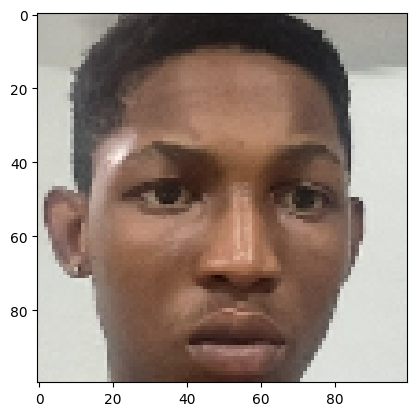

In [14]:
plt.imshow(img)

In [15]:
positives = tf.data.Dataset.zip((anchor,positive, tf.data.Dataset.from_tensor_slices(tf.ones(len(anchor)))))
negatives = tf.data.Dataset.zip((anchor,negative, tf.data.Dataset.from_tensor_slices(tf.zeros(len(anchor)))))
data = positives.concatenate(negatives)

In [16]:
samples = data.as_numpy_iterator()

In [17]:
example = samples.next()

In [18]:
def preprocess_twin(input_img,validation_img,label):
    return(preprocess(input_img),preprocess(validation_img),label)

In [19]:
res = preprocess_twin(*example)

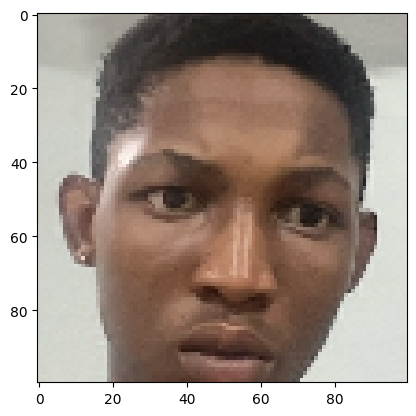

In [20]:
plt.imshow(res[1])

In [21]:
data = data.map(preprocess_twin)
data = data.cache()
data = data.shuffle(buffer_size=2048)

In [22]:
samples = data.as_numpy_iterator()

In [23]:
samp = samples.next()

2023-02-10 14:22:50.127226: W tensorflow/core/platform/profile_utils/cpu_utils.cc:128] Failed to get CPU frequency: 0 Hz


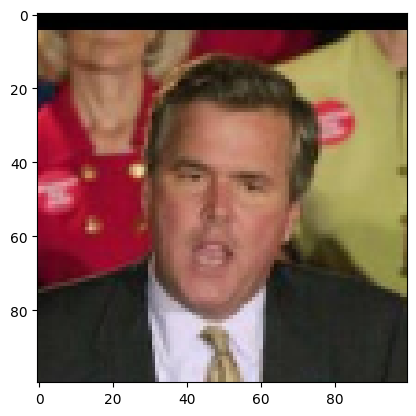

In [24]:
plt.imshow(samp[1])

In [25]:
samp[2]

0.0

In [26]:
train_data = data.take(round(len(data)*.7))
train_data = train_data.batch(16)
train_data = train_data.prefetch(8)

In [27]:
train_samples = train_data.as_numpy_iterator()

In [28]:
train_sample = train_samples.next()

In [29]:
len(train_sample[0])

16

In [30]:
test_data = data.skip(round(len(data)*.7))
test_data = test_data.take(round(len(data)*.3))
test_data = test_data.batch(16)
test_data = test_data.prefetch(8)

In [31]:
def make_embedding(): 
    inp = Input(shape=(100,100,3))
    
    c1 = Conv2D(64,(10,10),activation='relu')(inp)
    m1 = MaxPooling2D(64,(2,2),padding='same')(c1)
    
    c2 = Conv2D(128,(7,7),activation='relu')(m1)
    m2 = MaxPooling2D(64,(2,2),padding='same')(c2)
    
    c3 = Conv2D(128,(4,4),activation='relu')(m2)
    m3 = MaxPooling2D(64,(2,2),padding='same')(c3)
    
    c4 = Conv2D(256,(4,4),activation='relu')(m3)
    f1 = Flatten()(c4)
    d1 = Dense(4096,activation='sigmoid')(f1)
    
    return Model(inputs=[inp],outputs=[d1],name='embedding')

In [32]:
embedding = make_embedding()

In [33]:
embedding.summary()

Model: "embedding"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 100, 100, 3)]     0         
                                                                 
 conv2d (Conv2D)             (None, 91, 91, 64)        19264     
                                                                 
 max_pooling2d (MaxPooling2D  (None, 46, 46, 64)       0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 40, 40, 128)       401536    
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 20, 20, 128)      0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 17, 17, 128)       26

In [7]:
class L1Dist(Layer):
    def __init__(self,**kwargs):
        super().__init__()
        
    def call(self,input_embedding,validation_embedding):
        return tf.math.abs(input_embedding - validation_embedding)

In [6]:
l1 = L1Dist()

In [36]:
def make_siamese_model():
    
    input_image = Input(name='input_img',shape=(100,100,3))
    
    validation_image = Input(name='validation_img',shape=(100,100,3))
    
    siamese_layer = L1Dist()
    siamese_layer._name = 'distance'
    distances = siamese_layer(embedding(input_image),embedding(validation_image))
    
    classifier = Dense(1,activation='sigmoid')(distances)
    
    return Model(inputs=[input_image,validation_image],outputs=classifier,name='SiameseNetwork')

In [37]:
siamese_network = make_siamese_model()

In [38]:
siamese_network.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_img (InputLayer)         [(None, 100, 100, 3  0           []                               
                                )]                                                                
                                                                                                  
 validation_img (InputLayer)    [(None, 100, 100, 3  0           []                               
                                )]                                                                
                                                                                                  
 embedding (Functional)         (None, 4096)         38960448    ['input_img[0][0]',              
                                                                  'validation_img[0][

In [39]:
binary_cross_loss = tf.losses.BinaryCrossentropy()

In [40]:
opt = tf.keras.optimizers.Adam(1e-4)

In [41]:
checkpoint_dir = './training_checkpoints'
checkpoint_prefix = os.path.join(checkpoint_dir,'ckpt')
checkpoint = tf.train.Checkpoint(opt=opt,siamese_model=siamese_network)

In [42]:
from tensorflow.keras.metrics import Precision,Recall

In [43]:
@tf.function
def train_step(batch):
    with tf.GradientTape() as tape:
    
        X = batch[:2]
        y = batch[2]
        
        yhat = siamese_network(X,training=True)
        loss = binary_cross_loss(y,yhat)
    print(loss)
    grad = tape.gradient(loss ,siamese_network.trainable_variables)
    
    opt.apply_gradients(zip(grad,siamese_network.trainable_variables))
    return loss

In [44]:
def train(data, EPOCHS):
    early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',patience=10, restore_best_weights=True)
    # Loop through epochs
    for epoch in range(1, EPOCHS+1):
        print('\n Epoch {}/{}'.format(epoch, EPOCHS))
        progbar = tf.keras.utils.Progbar(len(data))
        
        # Creating a metric object 
        r = Recall()
        p = Precision()
        
        # Loop through each batch
        for idx, batch in enumerate(data):
            # Run train step here
            loss = train_step(batch)
            yhat = siamese_network.predict(batch[:2])
            r.update_state(batch[2], yhat)
            p.update_state(batch[2], yhat) 
            progbar.update(idx+1)
        print(loss.numpy(), r.result().numpy(), p.result().numpy())
        
        # Save checkpoints
        if epoch % 10 == 0: 
            checkpoint.save(file_prefix=checkpoint_prefix)
        if early_stopping.stopped_epoch > 0:
            print("Early stopping at epoch {}".format(epoch))
            break
        

In [45]:
EPOCHS = 50

In [242]:
train(train_data,EPOCHS)


 Epoch 1/50
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)
Tensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)


2023-02-10 12:40:43.341719: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.
2023-02-10 12:40:43.931902: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


43/44 [============================>.] - ETA: 2sTensor("binary_crossentropy/weighted_loss/value:0", shape=(), dtype=float32)


2023-02-10 12:42:29.303947: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


44/44 [==============================] - 108s 2s/step
0.038110178 0.6734104 0.99148935

 Epoch 2/50
44/44 [==============================] - 107s 2s/step
0.044075888 0.9885057 1.0

 Epoch 3/50
44/44 [==============================] - 108s 2s/step
0.002038761 0.97947216 1.0

 Epoch 4/50
44/44 [==============================] - 113s 3s/step
0.0030813054 0.99725276 1.0

 Epoch 5/50
44/44 [==============================] - 120s 3s/step
0.0015345071 1.0 1.0

 Epoch 6/50
44/44 [==============================] - 130s 3s/step
9.152604e-05 1.0 1.0

 Epoch 7/50
44/44 [==============================] - 1056s 24s/step
0.012382416 1.0 1.0

 Epoch 8/50
44/44 [==============================] - 346s 8s/step
5.0404046e-06 1.0 1.0

 Epoch 9/50
44/44 [==============================] - 108s 2s/step
0.0055579687 1.0 1.0

 Epoch 10/50
44/44 [==============================] - 107s 2s/step
0.00014142055 1.0 1.0

 Epoch 11/50
44/44 [==============================] - 107s 2s/step
0.00026985447 1.0 1.0

 Epoch 1

KeyboardInterrupt: 

In [43]:
test_input,test_val, y_true = test_data.as_numpy_iterator().next()

In [44]:
y_hat = siamese_network.predict([test_input,test_val])
y_hat

1/1 [==============================] - 0s 143ms/step


2023-02-10 14:21:33.152354: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:113] Plugin optimizer for device_type GPU is enabled.


array([[0.5007825 ],
       [0.5012331 ],
       [0.502018  ],
       [0.5014719 ],
       [0.5011232 ],
       [0.5021572 ],
       [0.5012957 ],
       [0.5029512 ],
       [0.5008891 ],
       [0.50235593],
       [0.5026433 ],
       [0.50258124],
       [0.50193584],
       [0.50104797],
       [0.5011998 ],
       [0.50217336]], dtype=float32)

In [45]:
[ 1 if prediction > 0.5 else 0 for prediction in y_hat ]

[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

In [46]:
y_true 

array([1., 0., 0., 1., 1., 0., 1., 0., 1., 0., 0., 0., 0., 1., 1., 0.],
      dtype=float32)

In [47]:
m = Recall()
m.update_state(y_true,y_hat)
m.result().numpy()

1.0

In [48]:
m = Precision()
m.update_state(y_true,y_hat)
m.result().numpy()

0.4375

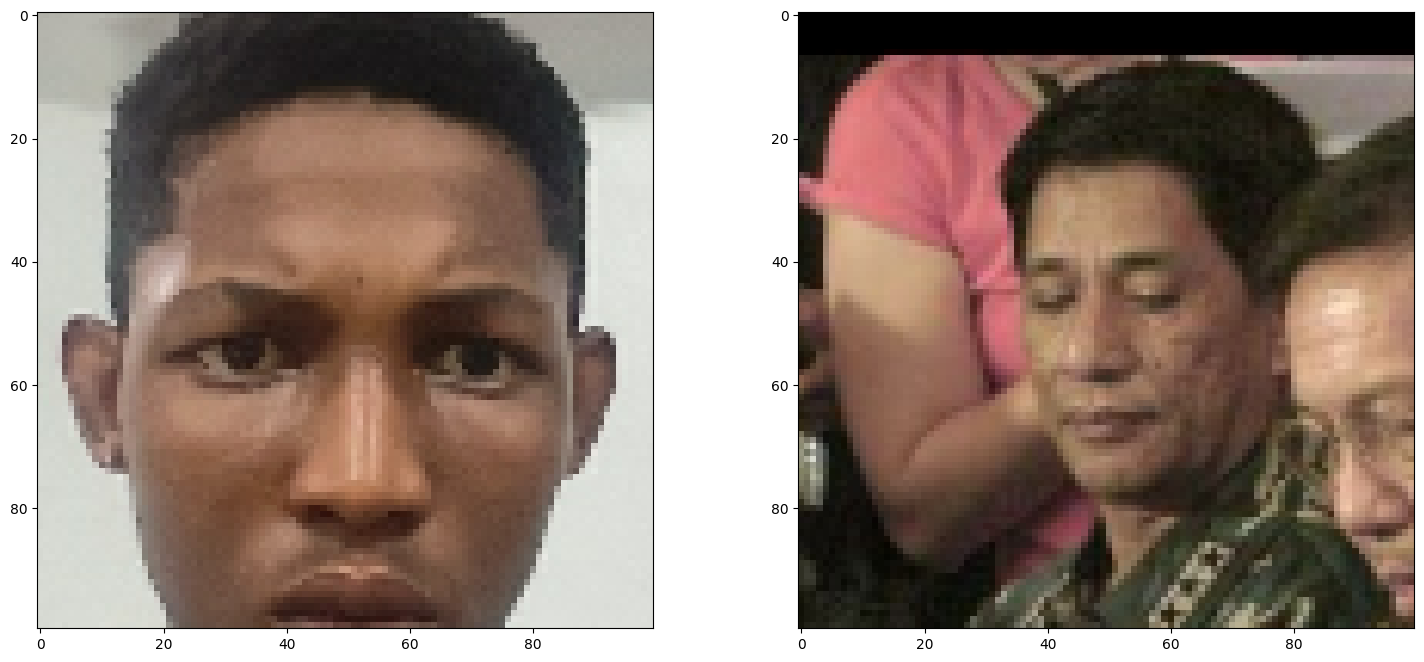

In [49]:
plt.figure(figsize=(18,8))
plt.subplot(1,2,1)
plt.imshow(test_input[5])
plt.subplot(1,2,2)
plt.imshow(test_val[5])

In [250]:
siamese_network.save('siamesemodel.h5')

In [8]:
model = tf.keras.models.load_model('siamesemodel.h5',custom_objects={'L1Dist':L1Dist,'BinaryCrossentropy':tf.losses.BinaryCrossentropy})

Metal device set to: Apple M1

systemMemory: 8.00 GB
maxCacheSize: 2.67 GB



2023-02-21 11:32:42.541992: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:306] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2023-02-21 11:32:42.542281: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:272] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [8]:
model.summary()

Model: "SiameseNetwork"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_img (InputLayer)         [(None, 100, 100, 3  0           []                               
                                )]                                                                
                                                                                                  
 validation_img (InputLayer)    [(None, 100, 100, 3  0           []                               
                                )]                                                                
                                                                                                  
 embedding (Functional)         (None, 4096)         38960448    ['input_img[0][0]',              
                                                                  'validation_img[0][

In [9]:
def verify(model,detection_threshold,verification_threshold):
    results = []
    
    for image in os.listdir(os.path.join('app_data','verification_images')):
        input_img = preprocess(os.path.join('app_data','input_images','input_image.jpg'))
        validation_img = preprocess(os.path.join('app_data','verification_images',image))
        
        result = model.predict(list(np.expand_dims([input_img,validation_img],axis=1)))
        results.append(result)
    
    detection = np.sum(np.array(results) > detection_threshold)
    verification = detection / len(os.listdir(os.path.join('app_data','verification_images')))
    verified = verification > verification_threshold
    return results, verified 

In [11]:
face_cascade = cv2.CascadeClassifier(cv2.data.haarcascades + 'haarcascade_frontalface_default.xml')

video_capture = cv2.VideoCapture(0)
frame_counter = 0



while True:
    # Capture frame-by-frame
    ret, frame = video_capture.read()

    # Reduce the frame size to half
    frame = cv2.resize(frame, (0,0), fx=0.5, fy=0.5) 

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.2,
        minNeighbors=5,
        minSize=(30, 30),
        flags=cv2.CASCADE_SCALE_IMAGE
    )

    # Draw a rectangle around the faces
    for (x, y, w, h) in faces:
        cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
        roi_color = frame[y:y+h, x:x+w]

        # Only process every 10th frame
        if frame_counter % 120 == 0 and len(faces) > 0:
            cv2.imwrite(os.path.join('app_data','input_images','input_image.jpg'), roi_color)
            results, verified = verify(model, 0.4, 0.9)
            print(verified)
        frame_counter += 1

# Display the resulting frame
    cv2.imshow('Video', frame)

    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# When everything is done, release the capture
video_capture.release()
cv2.destroyAllWindows()

1/1 [==============================] - 0s 13ms/step
False
1/1 [==============================] - 0s 13ms/step
True
1/1 [==============================] - 0s 13ms/step
True
1/1 [==============================] - 0s 13ms/step
False
1/1 [==============================] - 0s 13ms/step
False
1/1 [==============================] - 0s 13ms/step
False
1/1 [==============================] - 0s 13ms/step
False
1/1 [==============================] - 0s 13ms/step
False
1/1 [==============================] - 0s 12ms/step
False
1/1 [==============================] - 0s 13ms/step
False
1/1 [==============================] - 0s 13ms/step
False
1/1 [==============================] - 0s 16ms/step
False
1/1 [==============================] - 0s 13ms/step
False
1/1 [==============================] - 0s 13ms/step
False
1/1 [==============================] - 0s 12ms/step
True
1/1 [==============================] - 0s 12ms/step
True
1/1 [==============================] - 0s 16ms/step
False
1/1 [=============

KeyboardInterrupt: 